In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [80]:
df = pd.read_excel('hours_examscore_data.xlsx')
df.head()

,Hours_Studied,Exam_Score
0,0.20,43.4
1,0.21,41.8
2,0.27,30.4
3,0.30,35.8
4,0.39,35.1


In [81]:
df.describe()

,Hours_Studied,Exam_Score
count,100.000000,99.000000
mean,5.033900,66.129293
std,2.966425,18.604604
min,0.200000,30.400000
25%,2.145000,51.250000
50%,5.740000,70.000000
75%,7.745000,81.850000
max,9.720000,100.000000


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  100 non-null    float64
 1   Exam_Score     99 non-null     float64
dtypes: float64(2)
memory usage: 1.7 KB


In [83]:
df.shape

(100, 2)

In [84]:
df.isna().sum()

Hours_Studied    0
Exam_Score       1
dtype: int64

In [85]:
# exam score has null values we are going to drop it
df.dropna()

,Hours_Studied,Exam_Score
0,0.20,43.4
1,0.21,41.8
2,0.27,30.4
3,0.30,35.8
4,0.39,35.1
...,...,...
95,9.38,93.8
96,9.45,100.0
97,9.60,90.7
98,9.61,90.5


In [86]:
df.duplicated().sum() # no duplicate value

np.int64(0)

In [87]:
df.dtypes

Hours_Studied    float64
Exam_Score       float64
dtype: object

In [88]:
df['Hours_Studied'] = pd.to_numeric(df['Hours_Studied'], errors='coerce')

In [89]:
df['Exam_Score'] = pd.to_numeric(df['Exam_Score'], errors='coerce')

In [90]:
df.dtypes

Hours_Studied    float64
Exam_Score       float64
dtype: object

In [91]:
df['Hours_Studied'] = df['Hours_Studied'].astype(int)

In [92]:
df['Exam_Score'] = df['Exam_Score'].fillna(0).astype(int)

In [93]:
df.dtypes

Hours_Studied    int64
Exam_Score       int64
dtype: object

In [94]:
# Validate ranges: Hours_Studied ≥ 0 and Exam_Score between 0 and 100.
invalid_hours = df[df.Hours_Studied < 0]
print(invalid_hours)

Empty DataFrame
Columns: [Hours_Studied, Exam_Score]
Index: []


In [95]:
invalid_score = (df[df.Exam_Score < 0]) | (df.Exam_Score > 100)
print(invalid_hours)

Empty DataFrame
Columns: [Hours_Studied, Exam_Score]
Index: []


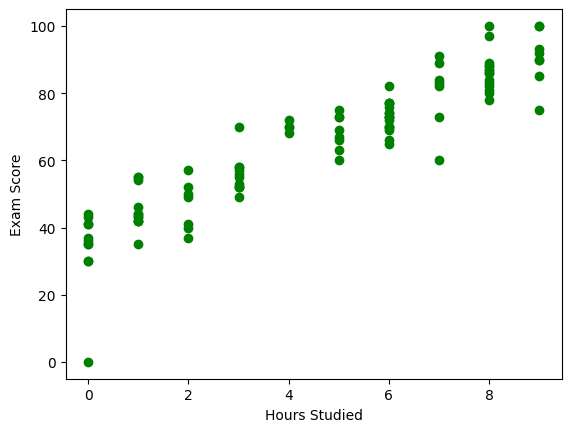

In [96]:
plt.scatter(df.Hours_Studied, df.Exam_Score, color='green')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

In [97]:
from sklearn.model_selection import train_test_split

In [98]:
X_train, X_test, y_train, y_test = train_test_split(df[['Hours_Studied']], df[['Exam_Score']], test_size=0.2, random_state=42)

In [99]:
len(X_train)

80

In [100]:
len(X_test)

20

In [101]:
from sklearn.preprocessing import StandardScaler

In [102]:
scaler = StandardScaler()

In [103]:
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [104]:
from sklearn.linear_model import LinearRegression

In [105]:
model = LinearRegression()

model.fit(X_train_norm, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [106]:
model.score(X_test_norm, y_test)

0.7541821483904121

In [129]:
from sklearn.metrics import mean_absolute_error

y_test_pred = model.predict(X_test_norm)
mean_absolute = mean_absolute_error(y_test, y_test_pred)
print("Mean absolute error", mean_absolute)

Mean absolute error 65.55570871497233


In [130]:
from sklearn.metrics import mean_squared_error

mean_squared = mean_squared_error(y_test, y_test_pred)
print("Mean squared error", np.sqrt(mean_squared))

Mean squared error 66.49213144779362


In [131]:
from sklearn.metrics import r2_score

r2_score_error = r2_score(y_test, y_test_pred)
print("R2", r2_score_error)

R2 -7.787747300730787


In [132]:
y_train_pred = model.predict(X_train_norm)

metrics_summary = {
    'Dataset': ['Train', 'Test'],
    'MAE': [
        mean_absolute_error(y_train, y_train_pred),
        mean_absolute_error(y_test, y_test_pred)
    ],
    'RMSE': [
        np.sqrt(mean_absolute_error(y_train, y_train_pred)),
        np.sqrt(mean_absolute_error(y_test, y_test_pred))
    ],
    'R2': [
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)
    ]
}

In [133]:
table = pd.DataFrame(metrics_summary)
table.head()

,Dataset,MAE,RMSE,R2
0,Train,65.700000,8.105554,-11.417216
1,Test,65.555709,8.096648,-7.787747
